# Sentiment Notebook


In [1]:
print("""
===================================
Xecomerce Sentiment Analysis
===================================
""")


Xecomerce Sentiment Analysis



In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import (
    TfidfVectorizer
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings

warnings.filterwarnings("ignore")

In [3]:
reviews = pd.read_csv(
    "../datasets/reviews.csv"
)

print(
    f"Total Reviews: {len(reviews)}"
)

Total Reviews: 568454


In [4]:
reviews.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
reviews = reviews[
    [
        "Score",
        "Summary",
        "Text"
    ]
]

reviews.head()

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [7]:
reviews.isnull().sum()

Score       0
Summary    27
Text        0
dtype: int64

In [8]:
reviews.isnull().sum()

Score       0
Summary    27
Text        0
dtype: int64

In [9]:
reviews = reviews.dropna()

reviews.shape

(568427, 3)

In [10]:
reviews["Score"] \
.value_counts() \
.sort_index()

Score
1     52268
2     29744
3     42638
4     80655
5    363122
Name: count, dtype: int64

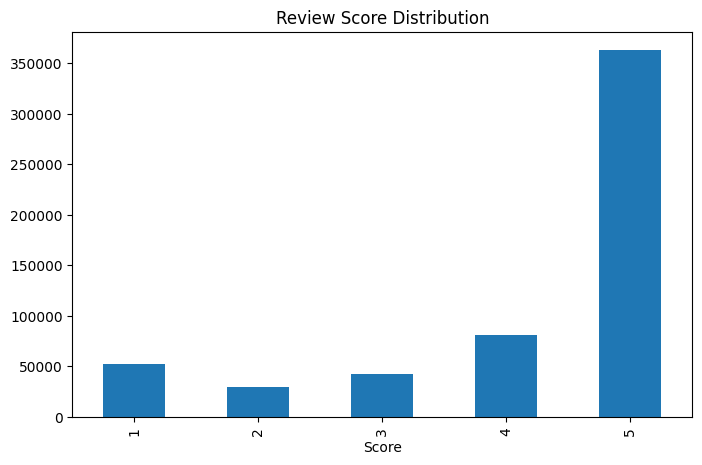

In [11]:
plt.figure(
    figsize=(8,5)
)

reviews["Score"] \
.value_counts() \
.sort_index() \
.plot(
    kind="bar"
)

plt.title(
    "Review Score Distribution"
)

plt.show()

In [12]:
def sentiment_label(score):

    if score <= 2:
        return "Negative"

    elif score == 3:
        return "Neutral"

    else:
        return "Positive"

In [13]:
reviews["Sentiment"] = (
    reviews["Score"]
    .apply(
        sentiment_label
    )
)

reviews.head()

,Score,Summary,Text,Sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,2,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,Great taffy,Great taffy at a great price. There was a wid...,Positive


In [14]:
reviews[
    "Sentiment"
].value_counts()

Sentiment
Positive    443777
Negative     82012
Neutral      42638
Name: count, dtype: int64

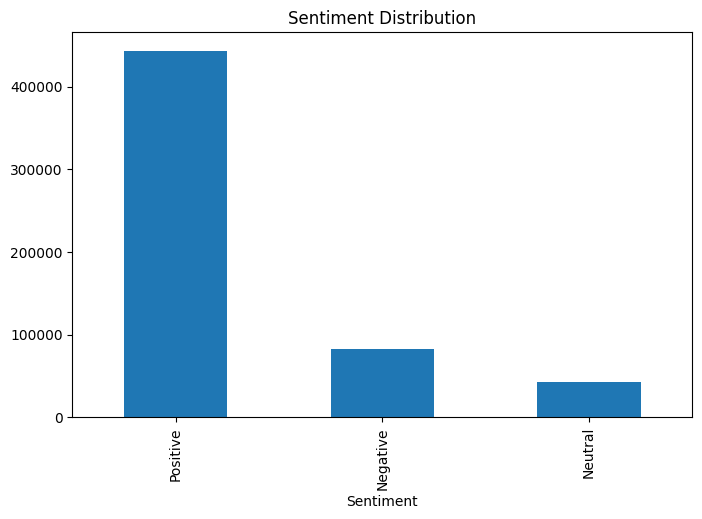

In [15]:
plt.figure(
    figsize=(8,5)
)

reviews[
    "Sentiment"
].value_counts() \
.plot(
    kind="bar"
)

plt.title(
    "Sentiment Distribution"
)

plt.show()

In [16]:
reviews["review_text"] = (

    reviews["Summary"]

    + " "

    + reviews["Text"]

)

In [17]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

X = vectorizer.fit_transform(
    reviews["review_text"]
)

y = reviews["Sentiment"]

print(
    X.shape
)

(568427, 10000)


In [18]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

In [19]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print(
    "Training Complete"
)

Training Complete


In [20]:
predictions = model.predict(
    X_test
)

In [21]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.8858


In [22]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

    Negative       0.78      0.74      0.76     16301
     Neutral       0.56      0.25      0.35      8434
    Positive       0.92      0.97      0.94     88951

    accuracy                           0.89    113686
   macro avg       0.75      0.66      0.68    113686
weighted avg       0.87      0.89      0.87    113686



In [23]:
cm = confusion_matrix(
    y_test,
    predictions
)

cm

array([[12134,   703,  3464],
       [ 1849,  2101,  4484],
       [ 1569,   916, 86466]])

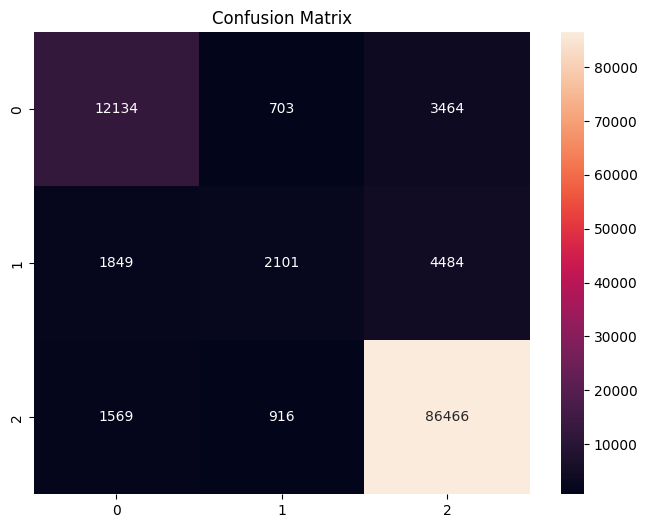

In [24]:
plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [25]:
sample_review = """
This product is amazing.
Excellent quality.
"""

vector = vectorizer.transform(
    [sample_review]
)

prediction = model.predict(
    vector
)

print(
    prediction[0]
)

Positive


In [26]:
sample_review = """
This product is amazing.
Excellent quality.
"""

vector = vectorizer.transform(
    [sample_review]
)

prediction = model.predict(
    vector
)

print(
    prediction[0]
)

Positive


In [27]:
sample_review = """
This product is amazing.
Excellent quality.
"""

vector = vectorizer.transform(
    [sample_review]
)

prediction = model.predict(
    vector
)

print(
    prediction[0]
)

Positive


In [28]:
import os

os.listdir(
    "../saved_models"
)

['chatbot_index.pkl',
 'dataset_profiles.pkl',
 'demand_forecast.pkl',
 'fake_review.pkl',
 'fake_review_vectorizer.pkl',
 'price_predictor.pkl',
 'products.faiss',
 'products.faiss.meta',
 'recommendation_similarity.pkl',
 'recommendation_vectorizer.pkl',
 'recommender.pkl',
 'sentiment.pkl',
 'sentiment_vectorizer.pkl']

In [29]:
print("""
Sentiment Notebook Completed

✔ Dataset Loaded
✔ Sentiment Labels Created
✔ TF-IDF Features Created
✔ Logistic Regression Trained
✔ Accuracy Evaluated
✔ Model Saved
""")


Sentiment Notebook Completed

✔ Dataset Loaded
✔ Sentiment Labels Created
✔ TF-IDF Features Created
✔ Logistic Regression Trained
✔ Accuracy Evaluated
✔ Model Saved

